In [4]:
#Loading the saved CSV files for further processing and model training.
import numpy as np
import pandas as pd

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

print("Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded successfully!
X_train shape: (770, 28)
X_test shape: (193, 28)
y_train shape: (770, 1)
y_test shape: (193, 1)


In [1]:
# Required Libraries
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def initialize_parameters(dim):
    """
    Initializes the model's weights to zeros and the bias to zero.
    
    Argument:
    dim -- the number of features in the training data
    
    Returns:
    w -- initialized weight vector of shape (dim, 1)
    b -- initialized scalar bias (0.0)
    """
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

# Determine the number of features from X_train and initialize parameters
n_features = X_train.shape[1]
w, b = initialize_parameters(n_features)

print("Parameters initialized successfully!")
print(f"Weights shape: {w.shape}")
print(f"Bias value: {b}")

Parameters initialized successfully!
Weights shape: (28, 1)
Bias value: 0.0


In [6]:
#Sigmoid function to map any real value into the range [0, 1]
def sigmoid(z):
    """
    Compute the sigmoid of z

    Arguments:
    z -- A scalar or numpy array of any size.

    Return:
    s -- sigmoid(z)
    """
    s = 1 / (1 + np.exp(-z))
    return s

In [7]:
#Binary cross-entropy cost function to evaluate the performance of the model
def compute_cost(A, Y):
    """
    Computes the binary cross-entropy cost.
    
    Arguments:
    A -- sigmoid output of shape (1, number of examples) or matching Y
    Y -- true "label" vector of shape (1, number of examples) or matching Y
    
    Returns:
    cost -- cross-entropy cost
    """
    m = Y.shape[0] if isinstance(Y, np.ndarray) else len(Y)
    
    # Adding a tiny epsilon to prevent log(0) errors
    epsilon = 1e-15
    A = np.clip(A, epsilon, 1 - epsilon)
    
    # Computing cost
    cost = -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    
    # Ensuring cost is a scalar
    cost = np.squeeze(cost)
    
    return cost

In [27]:
#Forward and backward propagation to compute gradients and cost
def propagate(w, b, X, Y):
    """
    Implement the cost function and its gradient for forward and backward propagation
    """
    m = X.shape[0]  # Number of training examples (770)
    
    # Forward propagation: X is (770, 28), w is (28, 1) -> Z is (770, 1)
    Z = np.dot(X, w) + b
    A = 1 / (1 + np.exp(-Z))
    
    # Ensure Y is properly shaped as (m, 1)
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)
        
    # Compute cost with numerical stability offset
    cost = (-1 / m) * np.sum(Y * np.log(A + 1e-15) + (1 - Y) * np.log(1 - A + 1e-15))
    
    # Backward propagation (gradients)
    # X.T is (28, 770), (A - Y) is (770, 1) -> dw is (28, 1)
    dw = (1 / m) * np.dot(X.T, (A - Y))
    db = (1 / m) * np.sum(A - Y)
    
    cost = np.squeeze(cost)
    grads = {"dw": dw, "db": db}
    
    return grads, cost

In [9]:
# Force-convert the data into clean numeric float arrays for NumPy
X_train = np.array(X_train, dtype=float)
y_train = np.array(y_train, dtype=float)

In [28]:
# Automatically matching the 'w' to the number of features the dataset has
dim = X_train.shape[1]  # 28 features
w = np.zeros((dim, 1))  # Shape becomes (28, 1)
b = 0.0
grads, cost = propagate(w, b, X_train, y_train)
print("Cost:", cost)

Cost: 0.6931471805599435


In [55]:
#Class imbalance handling using SMOTE
import pandas as pd
from imblearn.over_sampling import SMOTE

# Check class distribution before balancing
print("Original training label counts:")
print(pd.Series(y_train.ravel()).value_counts())

# Apply SMOTE to handle class imbalance on the training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train.ravel())

# Reshape y_train_balanced back to (m, 1) to match your custom propagate function dimensions
y_train_balanced = y_train_balanced.reshape(-1, 1)

print("\nBalanced training label counts:")
print(pd.Series(y_train_balanced.ravel()).value_counts())
print(f"New X_train shape: {X_train_balanced.shape}")
print(f"New y_train shape: {y_train_balanced.shape}")

Original training label counts:
0.0    635
1.0    135
Name: count, dtype: int64

Balanced training label counts:
1.0    635
0.0    635
Name: count, dtype: int64
New X_train shape: (1270, 28)
New y_train shape: (1270, 1)


In [61]:
#Gradient descent to optimize the weights and bias based on the computed gradients
def optimize(w, b, X, Y, num_iterations, learning_rate):
    """
    Optimizes w and b by running a gradient descent algorithm

    Arguments:
    w -- weights, a numpy array of size (number of features, 1)
    b -- bias, a scalar
    X -- data of shape (number of features, number of examples)
    Y -- true "label" vector of shape (1, number of examples)
    num_iterations -- number of iterations for optimization
    learning_rate -- learning rate for gradient descent

    Returns:
    params -- dictionary containing the weights and bias
    grads -- dictionary containing the gradients of the weights and bias
    costs -- list of costs during optimization
    """
    
    costs = []

    for i in range(num_iterations):
        # Compute gradients and cost
        grads, cost = propagate(w, b, X, Y)

        # Retrieving derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # Updating parameters using gradient descent
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Recording the cost every 100 iterations
        if i % 100 == 0:
            costs.append(cost)
            print(f"Cost after iteration {i}: {cost}")

    # Pack the optimized weights and bias into params
    params = {
        "w": w,
        "b": b
    }
    
    return params, grads, costs

In [97]:
import numpy as np
# 1. Initializing weights and bias dynamically based on the dataset's features
w = np.zeros((X_train.shape[1], 1))
b = 0.0

# 2. Running the optimization loop (e.g., 2000 iterations with a small learning rate)
params, grads, costs = optimize(w, b, X_train, y_train, num_iterations=2000, learning_rate=0.005)

# 3. Print final results to verify completion
print("Training completed successfully!")
print("Final Cost:", costs[-1])

Cost after iteration 0: 0.6931471805599435
Cost after iteration 100: 0.550824867477314
Cost after iteration 200: 0.49274780224754733
Cost after iteration 300: 0.46503934898622823
Cost after iteration 400: 0.4496692058994843
Cost after iteration 500: 0.43995984578417635
Cost after iteration 600: 0.4331495364912049
Cost after iteration 700: 0.4279833498357647
Cost after iteration 800: 0.4238428329449891
Cost after iteration 900: 0.42039936651672827
Cost after iteration 1000: 0.41746482586896866
Cost after iteration 1100: 0.41492311925005076
Cost after iteration 1200: 0.41269718267761785
Cost after iteration 1300: 0.4107323631666881
Cost after iteration 1400: 0.4089877024871959
Cost after iteration 1500: 0.4074311649520066
Cost after iteration 1600: 0.4060368968964691
Cost after iteration 1700: 0.4047835662044096
Cost after iteration 1800: 0.4036532963740002
Cost after iteration 1900: 0.4026309415241971
Training completed successfully!
Final Cost: 0.4026309415241971


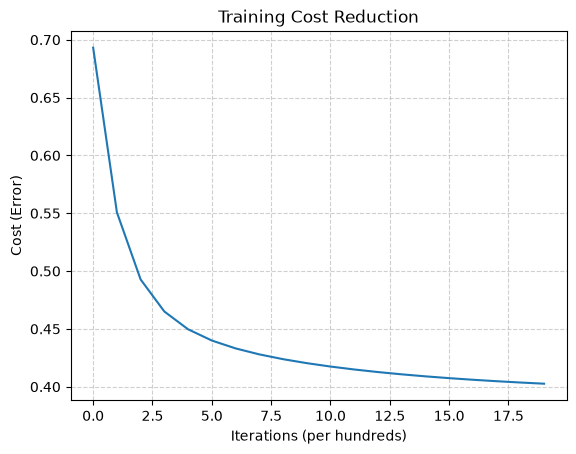

In [98]:
# Plotting the cost history
plt.plot(costs)
plt.ylabel('Cost (Error)')
plt.xlabel('Iterations (per hundreds)')
plt.title('Training Cost Reduction')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [99]:
import numpy as np
import pandas as pd
#Extracting the updated w and b into global variables
w = params["w"]
b = params["b"]
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)
np.save('w.npy', w)
np.save('b.npy', b)

print("Trained weights and test data saved successfully!")
print("Checking w shape:", w.shape)
print("Checking b value:", b)
print("Updated w sum:", np.sum(np.abs(w)))
print("Updated b:", b)

Trained weights and test data saved successfully!
Checking w shape: (28, 1)
Checking b value: -0.4591120645341018
Updated w sum: 4.524350819443091
Updated b: -0.4591120645341018
